In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# Download Apple stock data
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
df = df[["Close"]]
df.dropna(inplace=True)



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.400513
2020-01-03  71.696648
2020-01-06  72.267921
2020-01-07  71.928062
2020-01-08  73.085098


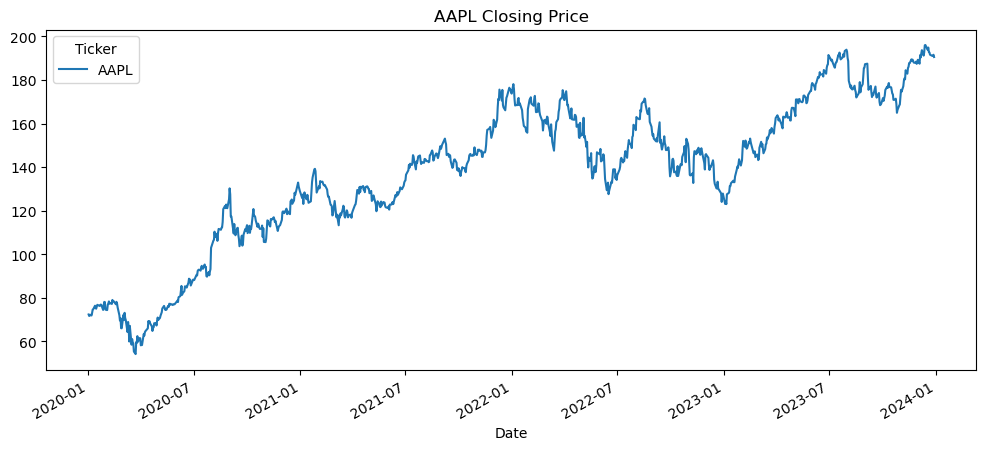

In [4]:
print(df.head())
df["Close"].plot(title="AAPL Closing Price", figsize=(12,5))
plt.show()

In [5]:
result = adfuller(df["Close"])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -1.5120
p-value: 0.5276


In [6]:
model = ARIMA(df["Close"], order=(5,1,0))
fitted = model.fit()
print(fitted.summary())

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1006
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2380.776
Date:                Tue, 17 Mar 2026   AIC                           4773.551
Time:                        20:20:46   BIC                           4803.028
Sample:                             0   HQIC                          4784.752
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0401      0.027     -1.475      0.140      -0.093       0.013
ar.L2         -0.0224      0.028     -0.806      0.420      -0.077       0.032
ar.L3         -0.0120      0.030     -0.399      0.6

In [9]:
forecast = fitted.forecast(steps=30)
forecast_index = pd.date_range(start=df.index[-1], periods=31, freq='B')[1:]
forecast_series = pd.Series(forecast.values, index=forecast_index)

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


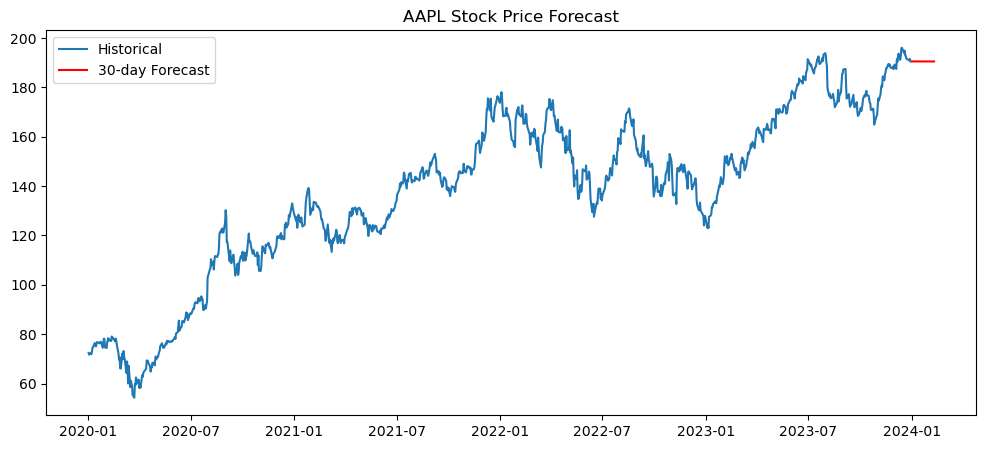

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df["Close"], label="Historical")
plt.plot(forecast_series, label="30-day Forecast", color="red")
plt.title("AAPL Stock Price Forecast")
plt.legend()
plt.show()